Think of the modelling process in this way:

Step 1: Split into features (X) and target (y), dropping the ID column

Step 2a: Feature grouping by data type and preprocessing tasks

Step 2b: Identify categorical and numeric features

Step 2c: Test for correlation between numeric features ( use Pearson as it is the most appropriate algorithm)

Step 2d: Test for correlation between categorical features (use Cramér’s V matrix as its better for categorical features)

Step 2e: Drop all correlated features

Step 3: Update categorical and numeric features lists (because you will possibly be dropping some correlated features)

Step 4: Build the preprocessing pipeline using ColumnTransformer

The preprocessing pipeline applies the correct transformation to each group of features based on their semantic meaning and data type:

One-hot encode string categorical features
Standard scale applied continuous numeric features
Min-max scale applied to bounded count (including capped count numeric features)
Binary flags (0 or 1) and ordinal features are numeric and left unchanged
Step 5: Set up the Random Forest model pipeline using the same preprocessor

Random Forest is an ensemble of decision trees that combines multiple models to improve stability and predictive performance. It handles mixed data types well, including one‑hot encoded categorical variables produced by the preprocessing pipeline, and naturally captures non‑linear relationships and interactions.

Step 6: Use GridSearchCV with cross‑validation  (or similar) to identify the optimal parameters and improve generalisation, especially in the presence of

class imbalance and complex feature interactions.

Step 7: fit the model and evaluate performance adding any fine tuning to improve performance

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.ensemble
from IPython.display import display
from scipy.stats import randint
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from pathlib import Path
#run the functions notebook which contains all the custome ASC data prep functions
%run include_functions.ipynb
%run evaluation_functions.ipynb
warnings.filterwarnings("ignore")

In [2]:
# TODO 1: update this path to match where your dataset is saved.
df_raw = pd.read_excel("OXON_HH_DATA.xlsx")

# TODO 2: confirm this is the correct target column in your dataset.
TARGET_RAW = "Incident?"

# This will be the cleaned 0/1 target column used for modelling.
TARGET = "target_incident"

# These are the ranked list sizes we want to evaluate.
# Keep this simple at first.
TOP_K_VALUES = [50, 100, 200, 500]

# Random seed so results are reproducible.
RANDOM_STATE = 42

# Data split sizes.
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_TRAIN = 0.25

# Random search size.
# Start with 25. Increase later if the notebook runs quickly.
# on my lap top the fitting process takes an exceedingly long time
# ... feel free to amend as per processing time of your system
N_ITER_SEARCH = 2

# Cross-validation folds.## 5 originally
CV_SPLITS = 5

# Turn off code that I do not want to run 
TURN_ON = False

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 301489 entries, 0 to 301488
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   s                                  301489 non-null  int64  
 1   ABP_Classification_Code            301489 non-null  str    
 2   ABP_Classification_Desc            301489 non-null  str    
 3   Communal Household Flag            301489 non-null  str    
 4   (H) Age - Fine                     301489 non-null  int64  
 5   (H) Household Composition          299873 non-null  float64
 6   (H) Presence of Elderly Parent     301489 non-null  int64  
 7   (H) Number of Adults in Household  301489 non-null  int64  
 8   (H) Family Lifestage v3            299873 non-null  float64
 9   (H) Length of Residency            301489 non-null  int64  
 10  (H) Property Type 2011             301489 non-null  int64  
 11  (H) Tenure 2011                    301489 non-null

In [4]:
null_count(df_raw)

,Field,Null Count,Null Pct
0,s,0,0.0
1,ABP_Classification_Code,0,0.0
2,ABP_Classification_Desc,0,0.0
3,Communal Household Flag,0,0.0
4,(H) Age - Fine,0,0.0
5,(H) Household Composition,1616,0.5
6,(H) Presence of Elderly Parent,0,0.0
7,(H) Number of Adults in Household,0,0.0
8,(H) Family Lifestage v3,1616,0.5
9,(H) Length of Residency,0,0.0


In [5]:
df_raw["Incident?"].value_counts(dropna=False)

Incident?
N    298648
Y      2841
Name: count, dtype: int64

In [6]:
df_raw["Incident?"].value_counts(dropna=False, normalize  = True)


Incident?
N    0.990577
Y    0.009423
Name: proportion, dtype: float64

In [7]:
nulls = null_count(df_raw)
null_list = list(nulls[nulls['Null Count']!=0]['Field'])
null_list

['(H) Household Composition', '(H) Family Lifestage v3']

In [8]:
# Check out the missing values
missing_columns = null_list
#    [    
    #"(H) Household Composition",# Check out the missing values
missing_columns = null_list
#    [    
    #"(H) Household Composition",
    #"(H) Family Lifestage v3"
#]

df_raw[missing_columns].isna().sum()
    #"(H) Family Lifestage v3"
#]

df_raw[missing_columns].isna().sum()

(H) Household Composition    1616
(H) Family Lifestage v3      1616
dtype: int64

In [9]:
# drop columns that are no longer required, in list form
columns_to_drop = [
    "ABP_Classification_Code",
    "(H) Mosaic UK 7 Type",
    "(H) Property Type 2011"
]

df_raw.drop(
    columns=columns_to_drop,
    inplace=True,
    errors="ignore"
)

# rename coloumns 
columns = {
    "s": "Addressbase UPRN",
    "irs.Incident?": "Incident?"
}
df_raw.rename(
    columns=columns,
    inplace=True
)

In [10]:
df_raw.shape


(301489, 19)

In [11]:
binary_columns=[
    "(H) Fuel Poverty v2 Flag",
    "Communal Household Flag"
]

for column in binary_columns:
    df_raw[column] = df_raw[column].map(
        {
            "N": 0, 
            "Y": 1
        }
    )


In [12]:
# a simplier clearner alternative to the generic funtion 

# Build a new modelling dataframe
df = df_raw.copy()

# convert target from Y/N to 1/0
# use the map function to map Y to 1 and N to 0
df[TARGET] = (
    df[TARGET_RAW]
    .str.strip()                  # remove any possible whitespace
    .str.upper()                  # convert all text to uppercase -safey code 
    .map(
        {
            "N": 0,
            "Y": 1
        }
    )
    .astype("Int64")
)

# Validate tat the mapping has wprked as expected 
# If he column contains anything unexpeted you will get an error message 
if df[TARGET].isna().any():
    raise ValueError(
        f"Unexpected values found in "
        f" '{TARGET_RAW}' ."
    )

# visually check the values in TARGET
print("\nCleaned target values:")
display(
    df[TARGET]
    .value_counts(dropna=False)
    .to_frame("count")
)



Cleaned target values:


,count
target_incident,
0,298648
1,2841


In [13]:
# These columns will NOT be used as model features.
DROP_COLUMNS_AS_FEATURES = [
    TARGET_RAW,
    TARGET,
    "Addressbase UPRN",
    "Unnamed: 0",
    "Easting",
    "Northing",
    "FRSIncidentIdentifier",
    "IncidentCategory",
    "VictimsInvolved",
    "VictimType",
    "WasRescued",
     "LSOA11CD"
]

# These columns are useful for the final ranked output, if they exist.
ID_COLUMNS_FOR_OUTPUT = [
    "Addressbase UPRN",
    "Easting",
    "Northing",
    "LSOA11CD",
    "Property_Type",
    "Property_Description",
]

feature_columns = [
    col for col in df.columns
    if col not in DROP_COLUMNS_AS_FEATURES
]

id_columns = [
    col for col in ID_COLUMNS_FOR_OUTPUT
    if col in df.columns
]

print(f"Number of feature columns: {len(feature_columns)}")
print("\nFeature columns used by the model:")
print(feature_columns)

print("\nID/context columns kept for ranked output:")
print(id_columns)


Number of feature columns: 16

Feature columns used by the model:
['ABP_Classification_Desc', 'Communal Household Flag', '(H) Age - Fine', '(H) Household Composition', '(H) Presence of Elderly Parent', '(H) Number of Adults in Household', '(H) Family Lifestage v3', '(H) Length of Residency', '(H) Tenure 2011', '(H) Mosaic UK 7 Type Label', '(H) Affluence v2', '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3', '(H) Household Income v3 - Bands', 'Station_Ground_Code']

ID/context columns kept for ranked output:
['Addressbase UPRN', 'LSOA11CD']


In [14]:
X = df[feature_columns].copy()
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 301489 entries, 0 to 301488
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ABP_Classification_Desc            301489 non-null  str    
 1   Communal Household Flag            301489 non-null  int64  
 2   (H) Age - Fine                     301489 non-null  int64  
 3   (H) Household Composition          299873 non-null  float64
 4   (H) Presence of Elderly Parent     301489 non-null  int64  
 5   (H) Number of Adults in Household  301489 non-null  int64  
 6   (H) Family Lifestage v3            299873 non-null  float64
 7   (H) Length of Residency            301489 non-null  int64  
 8   (H) Tenure 2011                    301489 non-null  int64  
 9   (H) Mosaic UK 7 Type Label         301489 non-null  str    
 10  (H) Affluence v2                   301489 non-null  int64  
 11  (H) Water Poverty Flag             301489 non-null

In [15]:
#X = df[feature_columns].copy() 
y = df[TARGET].copy()

ids = df[id_columns].copy() if id_columns else pd.DataFrame(index=df.index)


# First split: train+validation vs test.
X_train_val, X_test, y_train_val, y_test, ids_train_val, ids_test = train_test_split(
    X,
    y,
    ids,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Second split: train vs validation.
X_train, X_valid, y_train, y_valid, ids_train, ids_valid = train_test_split(
    X_train_val,
    y_train_val,
    ids_train_val,
    test_size=VALIDATION_SIZE_WITHIN_TRAIN,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(y_train), len(y_valid), len(y_test)],
    "positives": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "positive_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
}, index=["train", "validation", "test"])

display(split_summary)


,rows,positives,positive_rate
train,180893,1705,0.009425
validation,60298,568,0.009420
test,60298,568,0.009420


## Step 2a: Feature Grouping by data type and preprocessing tasks

In [16]:
### added 3/8/26:
# Explicitly define the pipeline features rather than rely on pandas data identification.

numeric_features = X_train[['(H) Number of Adults in Household',
                            '(H) Number of Children v3'
                           ]].columns#.tolist()

categorical_features = X_train[['ABP_Classification_Desc',
                                '(H) Mosaic UK 7 Type Label',
                                'Station_Ground_Code',
                                '(H) Tenure 2011',
                                '(H) Fuel Poverty v2 Flag',
                                '(H) Presence of Elderly Parent',
                                '(H) Water Poverty Flag',
                                'Communal Household Flag',
                                # added 5/8/26
                                '(H) Household Composition', 
                                '(H) Family Lifestage v3',
                                    ]].columns#.tolist()

ordinal_features = X_train[['(H) Age - Fine',
                            # suppresssed 5/8/26
                            #'(H) Household Composition',
                            #'(H) Family Lifestage v3',
                            '(H) Length of Residency',
                            '(H) Affluence v2',
                            '(H) Household Income v3 - Bands'
                                ]].columns#.tolist()
    
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Ordinal features: {len(ordinal_features)}")


Numeric features: 2
Categorical features: 10
Ordinal features: 4


In [17]:
X_train[categorical_features].info()

<class 'pandas.DataFrame'>
Index: 180893 entries, 151069 to 19372
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ABP_Classification_Desc         180893 non-null  str    
 1   (H) Mosaic UK 7 Type Label      180893 non-null  str    
 2   Station_Ground_Code             180893 non-null  str    
 3   (H) Tenure 2011                 180893 non-null  int64  
 4   (H) Fuel Poverty v2 Flag        180893 non-null  int64  
 5   (H) Presence of Elderly Parent  180893 non-null  int64  
 6   (H) Water Poverty Flag          180893 non-null  int64  
 7   Communal Household Flag         180893 non-null  int64  
 8   (H) Household Composition       179923 non-null  float64
 9   (H) Family Lifestage v3         179923 non-null  float64
dtypes: float64(2), int64(5), str(3)
memory usage: 15.2 MB


In [18]:
X_train[numeric_features].info()

<class 'pandas.DataFrame'>
Index: 180893 entries, 151069 to 19372
Data columns (total 2 columns):
 #   Column                             Non-Null Count   Dtype
---  ------                             --------------   -----
 0   (H) Number of Adults in Household  180893 non-null  int64
 1   (H) Number of Children v3          180893 non-null  int64
dtypes: int64(2)
memory usage: 4.1 MB


In [19]:
X_train[ordinal_features].info()

<class 'pandas.DataFrame'>
Index: 180893 entries, 151069 to 19372
Data columns (total 4 columns):
 #   Column                           Non-Null Count   Dtype
---  ------                           --------------   -----
 0   (H) Age - Fine                   180893 non-null  int64
 1   (H) Length of Residency          180893 non-null  int64
 2   (H) Affluence v2                 180893 non-null  int64
 3   (H) Household Income v3 - Bands  180893 non-null  int64
dtypes: int64(4)
memory usage: 6.9 MB


In [20]:
X_train[numeric_features].info()

<class 'pandas.DataFrame'>
Index: 180893 entries, 151069 to 19372
Data columns (total 2 columns):
 #   Column                             Non-Null Count   Dtype
---  ------                             --------------   -----
 0   (H) Number of Adults in Household  180893 non-null  int64
 1   (H) Number of Children v3          180893 non-null  int64
dtypes: int64(2)
memory usage: 4.1 MB


### Step 2c: 
Test for correlation between numeric features ( use Pearson as it is the most appropriate algorithm)


In [21]:
import pandas as pd

# Sample DataFrame with NUMERIC features
data_num = X_train[numeric_features]

df_num = pd.DataFrame(data_num)

# Calculate Pearson correlation matrix
pearson_corr = df_num.corr(method='pearson')

pearson_corr

,(H) Number of Adults in Household,(H) Number of Children v3
(H) Number of Adults in Household,1.00000,0.12477
(H) Number of Children v3,0.12477,1.00000


In [22]:
# Sample DataFrame with ORDINAL features
data_ord = X_train[ordinal_features]

df_ord = pd.DataFrame(data_ord)

# Calculate Pearson correlation matrix
kendall_corr = df_ord.corr(method='kendall')

kendall_corr

,(H) Age - Fine,(H) Length of Residency,(H) Affluence v2,(H) Household Income v3 - Bands
(H) Age - Fine,1.000000,0.415070,0.232126,-0.228536
(H) Length of Residency,0.415070,1.000000,0.184202,-0.097373
(H) Affluence v2,0.232126,0.184202,1.000000,0.416613
(H) Household Income v3 - Bands,-0.228536,-0.097373,0.416613,1.000000


In [23]:
cor_target = abs(kendall_corr)
relevant_features = cor_target[kendall_corr<0.5]
#df[relevant_features.index].corr(method='kendall')
relevant_features

,(H) Age - Fine,(H) Length of Residency,(H) Affluence v2,(H) Household Income v3 - Bands
(H) Age - Fine,NaN,0.415070,0.232126,0.228536
(H) Length of Residency,0.415070,NaN,0.184202,0.097373
(H) Affluence v2,0.232126,0.184202,NaN,0.416613
(H) Household Income v3 - Bands,0.228536,0.097373,0.416613,NaN


In [24]:
from scipy.stats import pearsonr

def remove_correlated(df, cor_thresh1):
    
    """Remove DataFrame columns with low correlation with target column."""
    from copy import deepcopy 

    df_minimal = deepcopy(df) # Needed to not change the original.
    names_df = df.columns.values

    for i in names_df:
        names_df = df_minimal.columns.values
        if i not in names_df:
            continue
            
        i1 = np.where(names_df == i)[0][0]
        
        for j in names_df:
            names_df = df_minimal.columns.values
            j1 = np.where(names_df == j)[0][0]
            
            if j1> i1:
                cor_r,_ = pearsonr(df_minimal.iloc[:,i1],df_minimal.iloc[:,j1])
                if abs(cor_r) > abs(cor_thresh1):
                    df_minimal.drop(names_df[j1], axis=1, inplace=True) 

    return df_minimal


In [25]:
cor_thresh1 = 0.5
df_num_min = remove_correlated(df_num, cor_thresh1)
df_num_min.head(14)

,(H) Number of Adults in Household,(H) Number of Children v3
151069,2,2
22544,2,2
169506,2,0
165034,5,2
86056,1,0
137737,1,0
256663,2,0
70378,2,0
242799,2,0
165791,2,1


In [26]:
from scipy.stats import kendalltau

In [27]:
def remove_correlated(df, cor_thresh1):
    
    """Remove DataFrame columns with low correlation with target column."""
    from copy import deepcopy 

    df_minimal = deepcopy(df) # Needed to not change the original.
    names_df = df.columns.values

    for i in names_df:
        names_df = df_minimal.columns.values
        if i not in names_df:
            continue
            
        i1 = np.where(names_df == i)[0][0]
        
        for j in names_df:
            names_df = df_minimal.columns.values
            j1 = np.where(names_df == j)[0][0]
            
            if j1> i1:
                cor_r,_ = kendalltau(df_minimal.iloc[:,i1],df_minimal.iloc[:,j1])
                if abs(cor_r) > abs(cor_thresh1):
                    df_minimal.drop(names_df[j1], axis=1, inplace=True) 

    return df_minimal

In [28]:
cor_thresh1 = 0.5
df_ord_min = remove_correlated(df_ord, cor_thresh1)
df_ord_min.head(14)

,(H) Age - Fine,(H) Length of Residency,(H) Affluence v2,(H) Household Income v3 - Bands
151069,6,8,16,7
22544,7,11,14,4
169506,5,5,16,6
165034,5,4,4,1
86056,9,11,15,4
137737,11,5,18,2
256663,9,11,17,2
70378,6,11,13,4
242799,10,11,16,2
165791,5,11,3,2


## Step 3:

Update categorical and numeric features lists (because you will possibly be dropping some correlated features)

In [29]:
numeric_features = df_num_min.columns


In [30]:
ordinal_features = df_ord_min.columns


In [31]:
### added 3/8/26:
# Explicitly define the pipeline features rather than rely on pandas data identification.

numeric_features = X_train[['(H) Number of Adults in Household',
                            '(H) Number of Children v3'
                           ]].columns#.tolist()

categorical_features = X_train[['ABP_Classification_Desc',
                                '(H) Mosaic UK 7 Type Label',
                                'Station_Ground_Code',
                                '(H) Tenure 2011',
                                '(H) Fuel Poverty v2 Flag',
                                '(H) Presence of Elderly Parent',
                                '(H) Water Poverty Flag',
                                'Communal Household Flag',
                                # added 5/8/26
                                '(H) Household Composition', 
                                '(H) Family Lifestage v3',
                                    ]].columns#.tolist()

ordinal_features = X_train[['(H) Age - Fine',
                            # suppresssed 5/8/26
                            #'(H) Household Composition',
                            #'(H) Family Lifestage v3',
                            '(H) Length of Residency',
                            '(H) Affluence v2',
                            '(H) Household Income v3 - Bands'
                                ]].columns#.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Ordinal features: {len(ordinal_features)}")


Numeric features: 2
Categorical features: 10
Ordinal features: 4


In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
])

# Compatible with different scikit-learn versions.
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot),
])




### An Ordinal Encoder needs adding here??
# Added 4/8/26:
ordinal_encoder = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy="most_frequent")),
    #("ordinal_encoder", OrdinalEncoder(categories = ordinal_features)),
    ])



## Or perhaps a LabelEncoder ??

#label_encoder = Pipeline(steps = [
#    ("imputer", SimpleImputer(strategy="most_frequent")),
#    ("label_encoder", LabelEncoder()),
#    ])






preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("ordinal_encoder", ordinal_encoder, ordinal_features )
    ],
    remainder="drop",
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [33]:
## RandomForestClassifier

baseline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", sklearn.ensemble.RandomForestClassifier(   
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose =0
    )),
])

## FIT
baseline_rf.fit(X_train, y_train)

#baseline_valid_scores = get_scores(baseline_rf, X_valid)

#print("Baseline Random Forest — validation")
#print(f"ROC-AUC:           {roc_auc_score(y_valid, baseline_valid_scores):.3f}")
#print(f"Average Precision: {average_precision_score(y_valid, baseline_valid_scores):.3f}")

#display(top_k_capture_table(y_valid, baseline_valid_scores, TOP_K_VALUES, label="validation"))


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['ABP_Classification_Desc','Communal Household Flag','(H) Age - Fine',..., '(H) Number of Children v3','(H) Household Income v3 - Bands', 'Station_Ground_Code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-spe

In [34]:
baseline_valid_scores = get_scores(baseline_rf, X_valid)

print("Baseline Random Forest — validation")
print(f"ROC-AUC:           {roc_auc_score(y_valid, baseline_valid_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_valid, baseline_valid_scores):.3f}")

display(top_k_capture_table(y_valid, baseline_valid_scores, TOP_K_VALUES, label="validation"))

Baseline Random Forest — validation
ROC-AUC:           0.772
Average Precision: 0.275


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,validation,50,49,0.980,0.086268,0.088028,0.980,104.035282
1,validation,100,64,0.640,0.112676,0.176056,0.640,67.941408
2,validation,200,114,0.570,0.200704,0.352113,0.570,60.510317
3,validation,500,201,0.402,0.353873,0.880282,0.402,42.675697


In [35]:
baseline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['ABP_Classification_Desc','Communal Household Flag','(H) Age - Fine',..., '(H) Number of Children v3','(H) Household Income v3 - Bands', 'Station_Ground_Code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-spe

In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", sklearn.ensemble.RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose = 2
    )),
])

# first run
'''
param_distributions = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": [None, 5, 8, 12, 16, 24, 32,36,40],
    "model__min_samples_split": randint(2, 50),
    "model__min_samples_leaf": randint(1, 25),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__bootstrap": [True, False],

}
'''
'''
-- Output at 125 fits
parameter 125 fits	best_params
model__bootstrap	FALSE
model__class_weight	balanced_subsample
model__max_depth	32
model__max_features	0.3
model__min_samples_leaf	11
model__min_samples_split	25
model__n_estimators	672
'''
#second run:
param_distributions = {
    "model__bootstrap": [True, False],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
    "model__max_depth": [ 22,24, 30, 36],
    "model__max_features": ["sqrt", "log2",0.1, 0.2, 0.3],
    "model__min_samples_leaf": randint(9,14),
    "model__min_samples_split": randint(20,28),
    "model__n_estimators": randint(500, 800),
}


minority_count = int(y_train.value_counts().min())
n_splits = max(2, min(CV_SPLITS, minority_count))

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER_SEARCH,
    scoring={
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    },
    refit="average_precision",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
    return_train_score=True,
)


In [37]:
import time
start_time = time.time()

In [38]:
rf_search.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 599building tree 2 of 599
building tree 5 of 599
building tree 12 of 599
building tree 6 of 599
building tree 8 of 599
building tree 4 of 599
building tree 9 of 599
building tree 7 of 599
building tree 10 of 599
building tree 11 of 599

building tree 3 of 599
building tree 13 of 599
building tree 14 of 599
building tree 15 of 599
building tree 16 of 599
building tree 17 of 599
building tree 18 of 599
building tree 19 of 599
building tree 20 of 599
building tree 21 of 599building tree 22 of 599

building tree 23 of 599
building tree 24 of 599
building tree 25 of 599
building tree 26 of 599
building tree 27 of 599
building tree 28 of 599
building tree 29 of 599


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   10.2s


building tree 30 of 599
building tree 31 of 599
building tree 32 of 599
building tree 33 of 599
building tree 34 of 599
building tree 35 of 599
building tree 36 of 599
building tree 37 of 599
building tree 38 of 599
building tree 39 of 599
building tree 40 of 599
building tree 41 of 599
building tree 42 of 599
building tree 43 of 599
building tree 44 of 599
building tree 45 of 599
building tree 46 of 599building tree 47 of 599

building tree 48 of 599
building tree 49 of 599
building tree 50 of 599
building tree 51 of 599
building tree 52 of 599
building tree 53 of 599
building tree 54 of 599
building tree 55 of 599
building tree 56 of 599
building tree 57 of 599
building tree 58 of 599
building tree 59 of 599
building tree 60 of 599
building tree 61 of 599
building tree 62 of 599
building tree 63 of 599
building tree 64 of 599
building tree 65 of 599
building tree 66 of 599
building tree 67 of 599
building tree 68 of 599
building tree 69 of 599
building tree 70 of 599
building tree 71

[Parallel(n_jobs=-1)]: Done 138 tasks      | elapsed:  1.0min


building tree 151 of 599
building tree 152 of 599
building tree 153 of 599
building tree 154 of 599
building tree 155 of 599
building tree 156 of 599
building tree 157 of 599
building tree 158 of 599
building tree 159 of 599
building tree 160 of 599
building tree 161 of 599
building tree 162 of 599
building tree 163 of 599
building tree 164 of 599
building tree 165 of 599
building tree 166 of 599
building tree 167 of 599
building tree 168 of 599
building tree 169 of 599
building tree 170 of 599
building tree 171 of 599
building tree 172 of 599
building tree 173 of 599
building tree 174 of 599
building tree 175 of 599
building tree 176 of 599
building tree 177 of 599
building tree 178 of 599
building tree 179 of 599
building tree 180 of 599
building tree 181 of 599
building tree 182 of 599
building tree 183 of 599
building tree 184 of 599
building tree 185 of 599
building tree 186 of 599
building tree 187 of 599
building tree 188 of 599
building tree 189 of 599
building tree 190 of 599


[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:  2.6min


building tree 355 of 599
building tree 356 of 599
building tree 357 of 599
building tree 358 of 599
building tree 359 of 599
building tree 360 of 599
building tree 361 of 599
building tree 362 of 599
building tree 363 of 599
building tree 364 of 599
building tree 365 of 599
building tree 366 of 599
building tree 367 of 599
building tree 368 of 599
building tree 369 of 599
building tree 370 of 599
building tree 371 of 599
building tree 372 of 599
building tree 373 of 599
building tree 374 of 599
building tree 375 of 599
building tree 376 of 599
building tree 377 of 599
building tree 378 of 599
building tree 379 of 599
building tree 380 of 599
building tree 381 of 599
building tree 382 of 599
building tree 383 of 599
building tree 384 of 599
building tree 385 of 599
building tree 386 of 599
building tree 387 of 599
building tree 388 of 599
building tree 389 of 599
building tree 390 of 599
building tree 391 of 599
building tree 392 of 599
building tree 393 of 599
building tree 394 of 599


[Parallel(n_jobs=-1)]: Done 599 out of 599 | elapsed:  4.5min finished


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=2))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__class_weight': [None, 'balanced', ...], 'model__max_depth': [22, 24, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'average_precision': 'average_precision', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother case

In [39]:
print(f'N_ITER_SEARCH = {N_ITER_SEARCH}')
print(f'CV_SPLITS = {CV_SPLITS}')
print(f'fits = {N_ITER_SEARCH*CV_SPLITS}')

print("Best CV Average Precision:", rf_search.best_score_)
#print("Best parameters:")
for key, value in rf_search.best_params_.items():
    print(f"  {key}: {value}")

N_ITER_SEARCH = 2
CV_SPLITS = 5
fits = 10
Best CV Average Precision: 0.3145202223535214
  model__bootstrap: False
  model__class_weight: balanced_subsample
  model__max_depth: 30
  model__max_features: 0.1
  model__min_samples_leaf: 11
  model__min_samples_split: 27
  model__n_estimators: 599


In [40]:
for key, value in rf_search.best_params_.items():
    df_best_params = pd.DataFrame([{key}, {value}])
 
df_best_params_ = pd.DataFrame(columns = [f'parameter {N_ITER_SEARCH*CV_SPLITS} fits', 'best_params'], data = rf_search.best_params_.items())
df_best_params_


,parameter 10 fits,best_params
0,model__bootstrap,False
1,model__class_weight,balanced_subsample
2,model__max_depth,30
3,model__max_features,0.1
4,model__min_samples_leaf,11
5,model__min_samples_split,27
6,model__n_estimators,599


In [41]:
print("pipeline_Random_Forest fitted\n--- %s seconds ---" % (time.time() - start_time))

pipeline_Random_Forest fitted
--- 1811.4567580223083 seconds ---


In [42]:
best_rf = rf_search.best_estimator_
tuned_valid_scores = get_scores(best_rf, X_valid)

print("Tuned Random Forest — validation")
print(f"ROC-AUC:           {roc_auc_score(y_valid, tuned_valid_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_valid, tuned_valid_scores):.3f}")

valid_top_k = top_k_capture_table(y_valid, tuned_valid_scores, TOP_K_VALUES, label="validation")
display(valid_top_k)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 341 tasks      | elapsed:    0.6s


Tuned Random Forest — validation
ROC-AUC:           0.816
Average Precision: 0.282


[Parallel(n_jobs=12)]: Done 599 out of 599 | elapsed:    1.1s finished


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,validation,50,48,0.960,0.084507,0.088028,0.960,101.912113
1,validation,100,77,0.770,0.135563,0.176056,0.770,81.742007
2,validation,200,119,0.595,0.209507,0.352113,0.595,63.164278
3,validation,500,186,0.372,0.327465,0.880282,0.372,39.490944


In [43]:
comparison_rows = []

for model_name, scores in [
    ("Baseline RF", baseline_valid_scores),
    ("Tuned RF", tuned_valid_scores),
]:
    top_k = top_k_capture_table(y_valid, scores, TOP_K_VALUES, label="validation")
    top_50_row = top_k[top_k["k"] == min(50, len(y_valid))].iloc[0]

    comparison_rows.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_valid, scores),
        "average_precision": average_precision_score(y_valid, scores),
        "top_50_true_positives": top_50_row["positives_in_top_k"],
        "precision_at_50": top_50_row["precision_at_k"],
        "recall_at_50": top_50_row["recall_at_k"],
        "pct_of_max_possible_recall_at_50": top_50_row["pct_of_max_possible_recall"],
        "lift_at_50": top_50_row["lift_at_k"],
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

,model,roc_auc,average_precision,top_50_true_positives,precision_at_50,recall_at_50,pct_of_max_possible_recall_at_50,lift_at_50
0,Baseline RF,0.772098,0.274523,49,0.98,0.086268,0.98,104.035282
1,Tuned RF,0.816445,0.282046,48,0.96,0.084507,0.96,101.912113


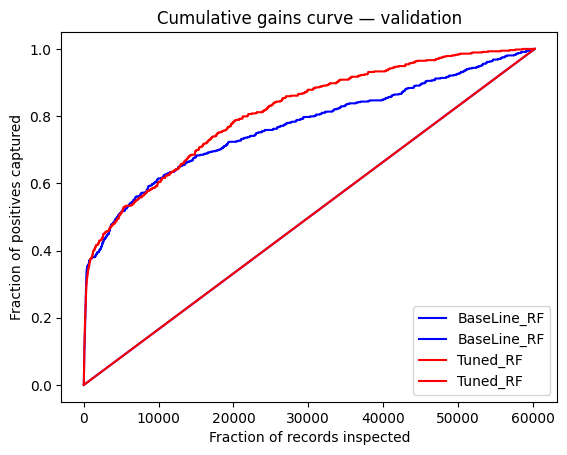

In [44]:
import matplotlib.pyplot as plt
import numpy as np


baseline_gain_valid = cumulative_gain_frame(y_valid, baseline_valid_scores)
tuned_gain_valid = cumulative_gain_frame(y_valid, tuned_valid_scores)
'''
ax1 = baseline_gain_valid.plot(
    x="inspected_fraction",
    y="cumulative_capture_rate",
    legend=False,
    title="Cumulative gains curve — validation — Baseline Random Forest",
)

ax2 = tuned_gain_valid.plot(
    x="inspected_fraction",
    y="cumulative_capture_rate",
    legend=False,
    title="Cumulative gains curve — validation — Tuned Random Forest",
)
'''


plt.plot(baseline_gain_valid, label = 'BaseLine_RF', color = 'blue')
plt.plot(tuned_gain_valid,    label = "Tuned_RF", color = 'red')


plt.legend(loc="lower right")

plt.xlabel("Fraction of records inspected")
plt.ylabel("Fraction of positives captured")
plt.title('Cumulative gains curve — validation')
plt.show()

In [45]:
final_model = best_rf

test_scores = get_scores(final_model, X_test)

print("Final tuned Random Forest — test")
print(f"ROC-AUC:           {roc_auc_score(y_test, test_scores):.3f}")
print(f"Average Precision: {average_precision_score(y_test, test_scores):.3f}")

test_top_k = top_k_capture_table(y_test, test_scores, TOP_K_VALUES, label="test")
display(test_top_k)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 341 tasks      | elapsed:    0.6s


Final tuned Random Forest — test
ROC-AUC:           0.841
Average Precision: 0.349


[Parallel(n_jobs=12)]: Done 599 out of 599 | elapsed:    1.5s finished


,dataset,k,positives_in_top_k,precision_at_k,recall_at_k,max_possible_recall_at_k,pct_of_max_possible_recall,lift_at_k
0,test,50,50,1.00,0.088028,0.088028,1.00,106.158451
1,test,100,92,0.92,0.161972,0.176056,0.92,97.665775
2,test,200,134,0.67,0.235915,0.352113,0.67,71.126162
3,test,500,215,0.43,0.378521,0.880282,0.43,45.648134


In [46]:
ids_test[:5]

,Addressbase UPRN,LSOA11CD
132303,100120778779,E01028506
42828,100120805884,E01028529
53498,10033018081,E01028653
70935,10033012484,E01028681
197367,100121297299,E01028595


In [47]:
ranked_test = ids_test.copy()
ranked_test["true_target"] = y_test.values
ranked_test["risk_score"] = test_scores
ranked_test["risk_rank"] = ranked_test["risk_score"].rank(method="first", ascending=False).astype(int)

ranked_test = ranked_test.sort_values("risk_score", ascending=False)
ranked_test = ranked_test.drop_duplicates(subset=['Addressbase UPRN'], keep='first') 
display(ranked_test.head(10))

# Save outputs for reporting.
ranked_test.to_csv("ranked_test_output.csv", index=False)
#ranked_test.head(50).to_csv("top_50_ranked_test_output.csv", index=False)

#print("Saved ranked_test_output.csv")
#print("Saved top_50_ranked_test_output.csv")

,Addressbase UPRN,LSOA11CD,true_target,risk_score,risk_rank
200256,10033007794,E01028653,1,0.999331,11
18500,10033018413,E01028671,1,0.965091,67
18511,10033018442,E01028671,1,0.965091,69
6538,10033018425,E01028671,1,0.965091,70
18503,10033018417,E01028671,1,0.965091,68
145,10033011232,E01028671,1,0.965067,71
131109,10014029560,E01028703,1,0.961445,73
131101,10014071512,E01028703,0,0.961445,72
16036,10033018447,E01028671,1,0.957384,78
25230,10033018414,E01028671,1,0.957384,79


In [48]:
display(ranked_test.head(100))

,Addressbase UPRN,LSOA11CD,true_target,risk_score,risk_rank
200256,10033007794,E01028653,1,0.999331,11
18500,10033018413,E01028671,1,0.965091,67
18511,10033018442,E01028671,1,0.965091,69
6538,10033018425,E01028671,1,0.965091,70
18503,10033018417,E01028671,1,0.965091,68
...,...,...,...,...,...
17770,10014027638,E01028756,0,0.858793,169
89613,10090812318,E01028673,1,0.858484,172
96334,10090812299,E01028673,1,0.858139,173
3813,10014026227,E01028692,1,0.857831,174


In [49]:
from sklearn.metrics import precision_score, roc_auc_score, mean_squared_error, accuracy_score
from sklearn.metrics import recall_score, classification_report, roc_curve, confusion_matrix
from sklearn import metrics

In [50]:
# Model Performance
# we can get performance of the model on the TRAIN data set from 
y_train_pred_best_rf =  best_rf.predict(X_train)
y_train_pred_best_rf

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 341 tasks      | elapsed:    2.1s
[Parallel(n_jobs=12)]: Done 599 out of 599 | elapsed:    5.2s finished


array([0., 0., 0., ..., 0., 0., 0.], shape=(180893,))

In [51]:
## 5. Evaluate on TRAINING SET: 
from sklearn.metrics import classification_report
target_names = ['0', '1']
print("TUNED MODEL: \nbest_rf(X_train)\n\nClassification Report:")
print(classification_report(y_train, y_train_pred_best_rf, target_names=target_names))

TUNED MODEL: 
best_rf(X_train)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    179188
           1       0.20      1.00      0.34      1705

    accuracy                           0.96    180893
   macro avg       0.60      0.98      0.66    180893
weighted avg       0.99      0.96      0.98    180893



In [73]:
# 5. Evaluate on TEST SET: 
y_test_pred_best_rf = best_rf.predict(X_test)
y_test_pred_best_rf

target_names = ['0', '1']
print("TEST MODEL: \nbest_rf(X_test)\n\nClassification Report:")
print(classification_report(y_test, y_test_pred_best_rf, target_names=target_names))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 341 tasks      | elapsed:    0.3s


TEST MODEL: 
best_rf(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     59730
           1       0.11      0.51      0.18       568

    accuracy                           0.96     60298
   macro avg       0.55      0.73      0.58     60298
weighted avg       0.99      0.96      0.97     60298



[Parallel(n_jobs=12)]: Done 599 out of 599 | elapsed:    0.6s finished


In [74]:
best_rf_pred_RF_ACCURACY =  metrics.accuracy_score( y_train,  y_train_pred_best_rf)
best_rf_pred_RF_PRECISION = metrics.precision_score(y_train,  y_train_pred_best_rf)
best_rf_pred_RF_RECALL =    metrics.recall_score(   y_train,  y_train_pred_best_rf)
best_rf_pred_RF_PF1 =       metrics.f1_score(       y_train,  y_train_pred_best_rf)

In [75]:
d = {"accuracy_score":  [metrics.accuracy_score(y_train, y_train_pred_best_rf),  metrics.accuracy_score( y_test, y_test_pred_best_rf)], 
     "precision_score": [metrics.precision_score(y_train, y_train_pred_best_rf), metrics.precision_score(y_test, y_test_pred_best_rf)],
     "recall_score":    [metrics.recall_score(y_train, y_train_pred_best_rf),    metrics.recall_score(   y_test, y_test_pred_best_rf)],
     "f1_score":        [metrics.f1_score(y_train, y_train_pred_best_rf),        metrics.f1_score(       y_test, y_test_pred_best_rf)]    
    }
print("RANDOM FOREST baseline: With respect to target variable = 1\n")
RF_metrics = pd.DataFrame(data=d, index=['TRAIN', 'TEST'])
RF_metrics = RF_metrics.T
RF_metrics


RANDOM FOREST baseline: With respect to target variable = 1



,TRAIN,TEST
accuracy_score,0.963371,0.956317
precision_score,0.204231,0.109008
recall_score,0.996481,0.507042
f1_score,0.338986,0.179439


<Figure size 1000x500 with 0 Axes>

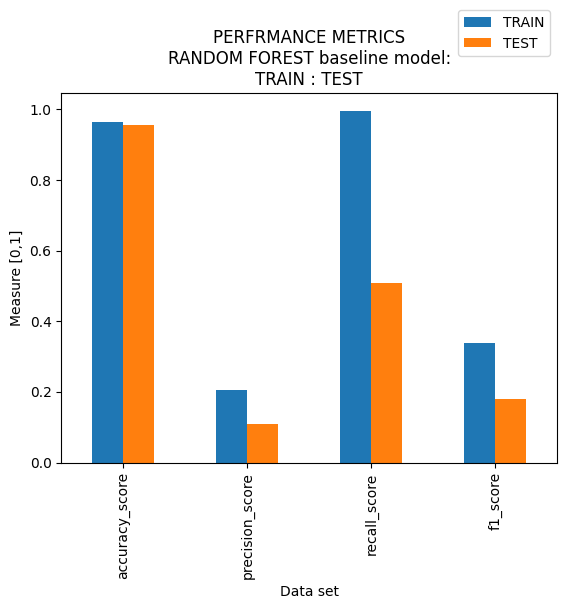

In [76]:
plt.figure(figsize = (10,5))
#RF_metrics[['accuracy_score','precision_score']].plot(kind = 'bar', legend = True)
#RF_metrics[['recall_score',	'f1_score']].plot(kind = 'bar', legend = True)

RF_metrics[['TRAIN','TEST']].plot(kind = 'bar', legend = True)
plt.title("PERFRMANCE METRICS\nRANDOM FOREST baseline model:\nTRAIN : TEST") 
#plt.legend(loc = " right")
plt.legend(loc=(0.8,1.1))
plt.xlabel('Data set')
plt.ylabel('Measure [0,1]')
plt.show()

In [77]:
y_test_pred_proba_baseline_rf =  baseline_rf.predict_proba(X_test)[:,1]
y_test_pred_proba_baseline_rf

array([0.00666667, 0.02333333, 0.00333333, ..., 0.        , 0.00666667,
       0.        ], shape=(60298,))

In [78]:
logit_roc_auc_baseline        = roc_auc_score(y_test,    y_test_pred_proba_baseline_rf)
print(f'ROC-AUC_score[y_test]: {logit_roc_auc_baseline}')

ROC-AUC_score[y_test]: 0.7949926960052632


In [79]:
fpr_baseline_rf, tpr_baseline_rf, thresholds = roc_curve(y_test,    y_test_pred_proba_baseline_rf)

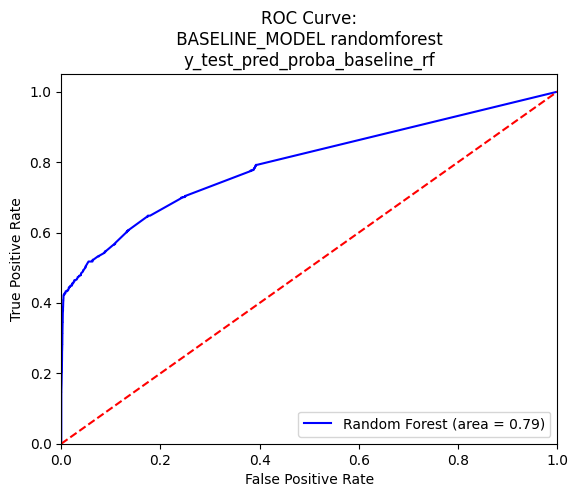

In [80]:
plt.figure()
plt.plot(fpr_baseline_rf, tpr_baseline_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_baseline,color = 'blue' )
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\n BASELINE_MODEL randomforest \ny_test_pred_proba_baseline_rf')
plt.legend(loc="lower right")
plt.show()

In [81]:
x = RF_metrics.T['precision_score'][1:][0:] 
#y = RF_metrics['precision_score'][0:][0:]
x


TEST    0.109008
Name: precision_score, dtype: float64

In [82]:
y_test_pred_proba_best_rf =  best_rf.predict_proba(X_test)[:,1]
y_test_pred_proba_best_rf

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 341 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 599 out of 599 | elapsed:    0.6s finished


array([0.20568688, 0.25615839, 0.18617839, ..., 0.03331395, 0.11817565,
       0.31242341], shape=(60298,))

In [83]:
logit_roc_auc_best_rf       = roc_auc_score(y_test,    y_test_pred_proba_best_rf)
print(f'ROC-AUC_score[y_test]: {logit_roc_auc_best_rf}')

ROC-AUC_score[y_test]: 0.840547428215703


In [84]:
fpr_best_rf, tpr_best_rf, thresholds = roc_curve(y_test,    y_test_pred_proba_best_rf)

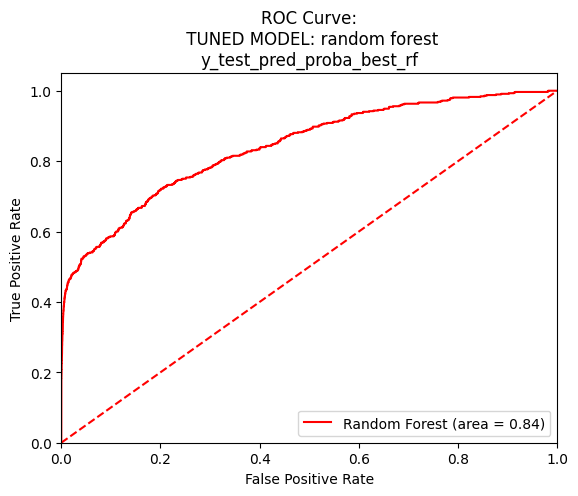

In [85]:
plt.figure()
plt.plot(fpr_best_rf, tpr_best_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_best_rf, color = 'red')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\n TUNED MODEL: random forest\ny_test_pred_proba_best_rf')
plt.legend(loc="lower right")
plt.show()

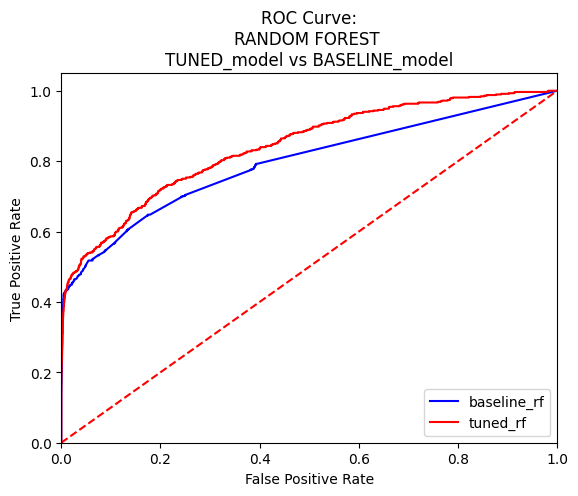

In [86]:
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve:\nRANDOM FOREST \nTUNED_model vs BASELINE_model')


plt.plot(fpr_baseline_rf, tpr_baseline_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_baseline, color = 'blue')
plt.plot(fpr_best_rf, tpr_best_rf, label='Random Forest (area = %0.2f)' % logit_roc_auc_best_rf, color = 'red')
plt.plot([0, 1], [0, 1],'r--')

plt.legend(labels = ['baseline_rf','tuned_rf'], loc="lower right")
plt.show()

In [87]:
data = {
  "Baseline_ROC_Score": logit_roc_auc_baseline,
  "Tuned_RF_ROC_Score": logit_roc_auc_best_rf
}
data


{'Baseline_ROC_Score': 0.7949926960052632,
 'Tuned_RF_ROC_Score': 0.840547428215703}

In [88]:
best_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[float64](2,)","[0.,1.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['ABP_Classification_Desc','Communal Household Flag','(H) Age - Fine',..., '(H) Number of Children v3','(H) Household Income v3 - Bands', 'Station_Ground_Code']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-spe

In [89]:
best_pipeline=rf_search.best_estimator_ 
print(best_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['(H) Number of Adults in Household', '(H) Number of Children v3'], dtype='str')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['A...
       'Station_Ground_Code', '(H) Tenure 2011', '(H) Fuel Poverty v2 Flag',
       '(H) Presence of Elderly Parent', '(H) Water Poverty Flag',
       'Communal Household Flag', '(H) Household Co

In [90]:
rf_model = best_pipeline.named_steps["model"]
feature_importances = rf_model.feature_importances_
feature_importances.sum()

np.float64(1.0)

Number of transformed features: 140
Number of importances: 140


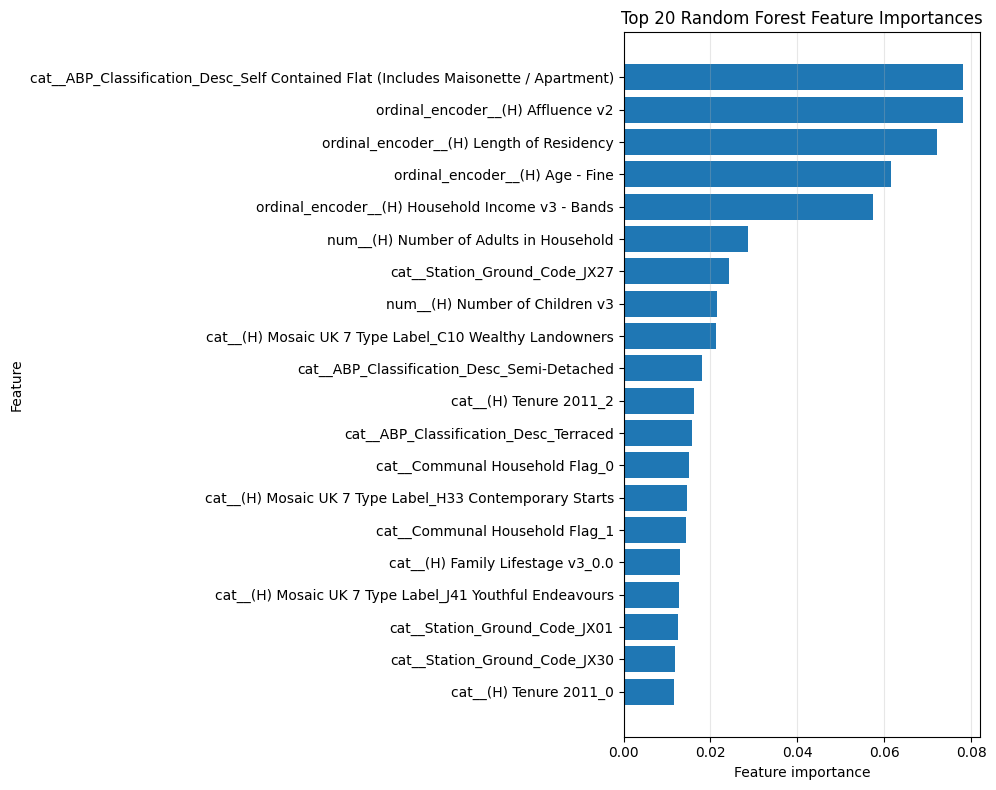

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
rf_model = best_pipeline.named_steps["model"]
feature_importances = rf_model.feature_importances_
preprocessor = best_pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
print("Number of transformed features:", len(feature_names))
print("Number of importances:", len(feature_importances))
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False)
top_features = importance_df.head(20).sort_values("Importance")
plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
 
 

In [92]:
importance_df

,Feature,Importance
7,cat__ABP_Classification_Desc_Self Contained Fl...,7.808239e-02
138,ordinal_encoder__(H) Affluence v2,7.801672e-02
137,ordinal_encoder__(H) Length of Residency,7.220180e-02
136,ordinal_encoder__(H) Age - Fine,6.160030e-02
139,ordinal_encoder__(H) Household Income v3 - Bands,5.746204e-02
...,...,...
9,cat__ABP_Classification_Desc_Sheltered Accommo...,9.102752e-05
122,cat__(H) Household Composition_11.0,1.898624e-05
5,cat__ABP_Classification_Desc_House Boat,4.901189e-08
67,cat__(H) Mosaic UK 7 Type Label_N59 Large Fami...,3.354015e-18


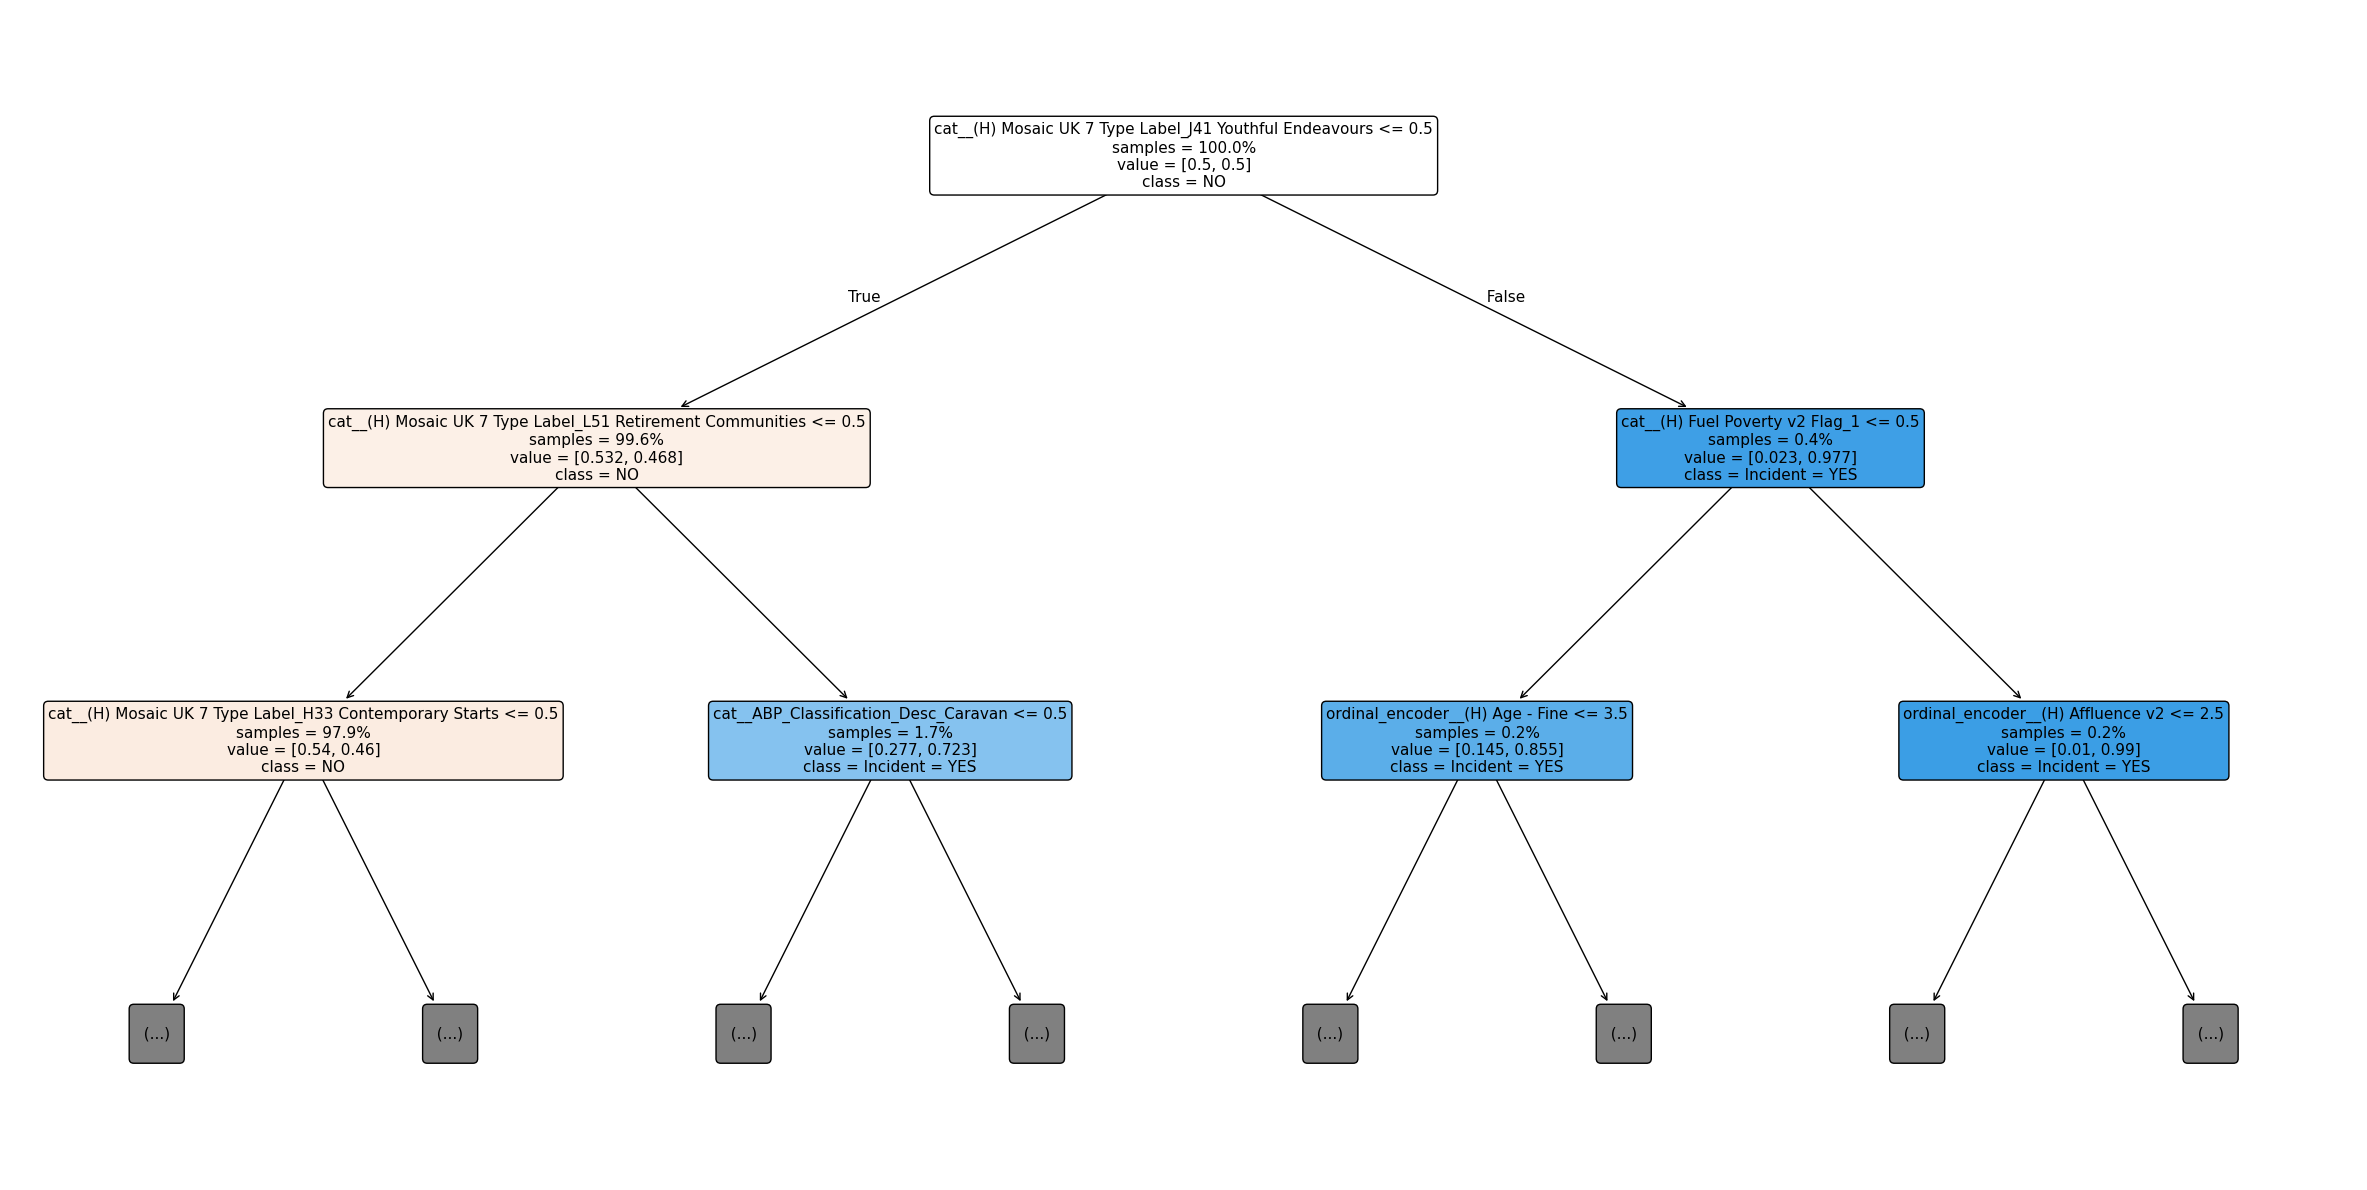

In [93]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
rf_model = best_rf.named_steps["model"]
example_tree = rf_model.estimators_[0]

plt.figure(figsize=(24, 12))
plot_tree(
    example_tree,
    max_depth=2,
    feature_names=feature_names,
    class_names=["NO", "Incident = YES"],
    filled=True,
    impurity=False,
    proportion=True,
    rounded=True,
    fontsize=11
)
plt.tight_layout()
plt.savefig("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/Documents for June 2026/images/DecsionTree_example.svg")#, bbox_inches="tight")
plt.savefig("DecsionTree_example.svg")#, bbox_inches="tight")
plt.show()